### Imports

In [ ]:
from utils.alternate_dataset import myDataset, TestSubset
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import GroupShuffleSplit
from models.simple_CNN_regression import PixelWiseRegressor
from models.downscaledUNet import UNetRegression, SimplePixelRegressor
from models.downscaledUNetSE import UNetRegressionSE
from models.DA_CNN import DA_CNN
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np


### Data Preparation

In [168]:
from utils.transforms import RescaledRotationTransform
transform = RescaledRotationTransform(scaling_interval=(1, 1.1))

In [169]:
dataset = myDataset(transform=transform, season="autumn", coarsen=3)
dataset[0][0].shape

torch.Size([8, 4, 4])

In [170]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_val_indices, test_indices = next(gss.split(dataset.indexes, groups=dataset.groups))
print(len(train_val_indices), len(test_indices))

16240 2030


In [171]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_groups = [dataset.groups[i] for i in train_val_indices]
train_indices, val_indices = next(gss.split(train_val_indices, groups=train_val_groups))
print(len(train_indices), len(val_indices))
train_indices 

13804 2436


array([    0,     1,     2, ..., 16237, 16238, 16239], shape=(13804,))

In [172]:
train_val_indices

array([    0,     1,     2, ..., 18267, 18268, 18269], shape=(16240,))

In [173]:
test_indices

array([10150, 10151, 10152, ..., 17861, 17862, 17863], shape=(2030,))

In [174]:
list1 = train_indices
list2 = test_indices

list(set(list1).intersection(set(list2)))

[np.int64(10240),
 np.int64(10241),
 np.int64(10242),
 np.int64(10243),
 np.int64(10244),
 np.int64(10245),
 np.int64(10246),
 np.int64(10247),
 np.int64(10248),
 np.int64(10249),
 np.int64(10250),
 np.int64(10251),
 np.int64(10252),
 np.int64(10253),
 np.int64(10254),
 np.int64(10255),
 np.int64(10256),
 np.int64(10257),
 np.int64(10258),
 np.int64(10259),
 np.int64(10260),
 np.int64(10261),
 np.int64(10262),
 np.int64(10263),
 np.int64(10264),
 np.int64(10265),
 np.int64(10266),
 np.int64(10267),
 np.int64(10268),
 np.int64(10269),
 np.int64(10270),
 np.int64(10271),
 np.int64(10272),
 np.int64(10273),
 np.int64(10274),
 np.int64(10275),
 np.int64(10276),
 np.int64(10277),
 np.int64(10278),
 np.int64(10279),
 np.int64(10280),
 np.int64(10281),
 np.int64(10282),
 np.int64(10283),
 np.int64(10284),
 np.int64(10285),
 np.int64(10286),
 np.int64(10287),
 np.int64(10288),
 np.int64(10289),
 np.int64(10290),
 np.int64(10291),
 np.int64(10292),
 np.int64(10293),
 np.int64(10294),
 np.int64(

In [175]:
[train_val_indices[i] for i in train_indices][8100:],

([np.int64(10130),
  np.int64(10131),
  np.int64(10132),
  np.int64(10133),
  np.int64(10134),
  np.int64(10135),
  np.int64(10136),
  np.int64(10137),
  np.int64(10138),
  np.int64(10139),
  np.int64(10140),
  np.int64(10141),
  np.int64(10142),
  np.int64(10143),
  np.int64(10144),
  np.int64(10145),
  np.int64(10146),
  np.int64(10147),
  np.int64(10148),
  np.int64(10149),
  np.int64(10962),
  np.int64(10963),
  np.int64(10964),
  np.int64(10965),
  np.int64(10966),
  np.int64(10967),
  np.int64(10968),
  np.int64(10969),
  np.int64(10970),
  np.int64(10971),
  np.int64(10972),
  np.int64(10973),
  np.int64(10974),
  np.int64(10975),
  np.int64(10976),
  np.int64(10977),
  np.int64(10978),
  np.int64(10979),
  np.int64(10980),
  np.int64(10981),
  np.int64(10982),
  np.int64(10983),
  np.int64(10984),
  np.int64(10985),
  np.int64(10986),
  np.int64(10987),
  np.int64(10988),
  np.int64(10989),
  np.int64(10990),
  np.int64(10991),
  np.int64(10992),
  np.int64(10993),
  np.int64(1

In [176]:
train_months = list(set([train_val_groups[i] for i in train_indices]))

val_months = list(set([train_val_groups[i] for i in val_indices]))

test_months = list(set([dataset.groups[i] for i in test_indices]))

print(train_months)
print(val_months)
print(test_months)

intersection_months = list(set(train_months) & set(test_months))
print("Intersection of train and test months:", intersection_months)


[129, 130, 131, 9, 10, 11, 141, 142, 21, 23, 153, 154, 155, 33, 34, 35, 166, 167, 45, 46, 47, 177, 179, 58, 59, 71, 81, 83, 93, 94, 95, 105, 117, 119]
[69, 70, 82, 22, 118, 57]
[165, 106, 107, 143, 178]
Intersection of train and test months: []


In [177]:
train_indices = [train_val_indices[i] for i in train_indices]
val_indices = [train_val_indices[i] for i in val_indices]

In [178]:
train_subset = Subset(dataset, train_indices)
test_subset = TestSubset(dataset, test_indices)
val_subset = TestSubset(dataset, val_indices)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=1, shuffle=False)
val_loader = DataLoader(val_subset, batch_size=1, shuffle=True)

In [179]:
print(dataset[0][0].shape, dataset[0][1].shape)

torch.Size([8, 4, 4]) torch.Size([])


In [186]:
dataset[0]

(tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  1.0755,  0.9942],
          [ 0.0000,  0.0000,  1.1105,  1.0548]],
 
         [[ 0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  1.1995,  1.2264],
          [ 0.0000,  0.0000,  0.9622,  0.9662]],
 
         [[ 0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000, -0.3564, -0.3125],
          [ 0.0000,  0.0000, -0.4206, -0.2826]],
 
         [[ 0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  1.9967,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000]],
 
         [[ 0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  1.3453,  1.3136],
          [ 0.0000,  0.0000,  1.5596,  1.5821]],
 
         [[ 0.0000,  0.00

Image shape: torch.Size([8, 4, 4]), Label shape: torch.Size([])


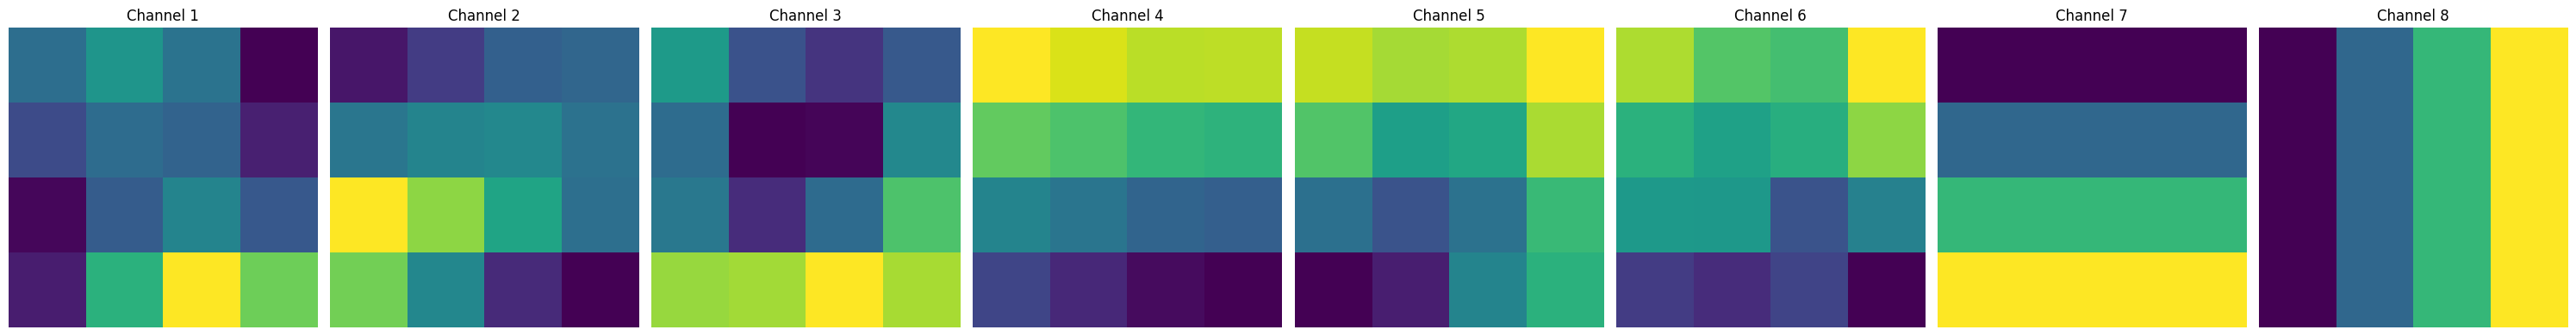

In [187]:
num = 52

img, label, _ = dataset[num]
print(f"Image shape: {img.shape}, Label shape: {label.shape}")
plt.figure(figsize=(30, 4))
for i in range(img.shape[0]):
    plt.subplot(1, img.shape[0], i + 1)
    plt.imshow(img[i], aspect='auto', cmap='viridis')
    plt.title(f'Channel {i+1}')
    plt.axis('off')
plt.axis('off')
plt.tight_layout()
plt.show()

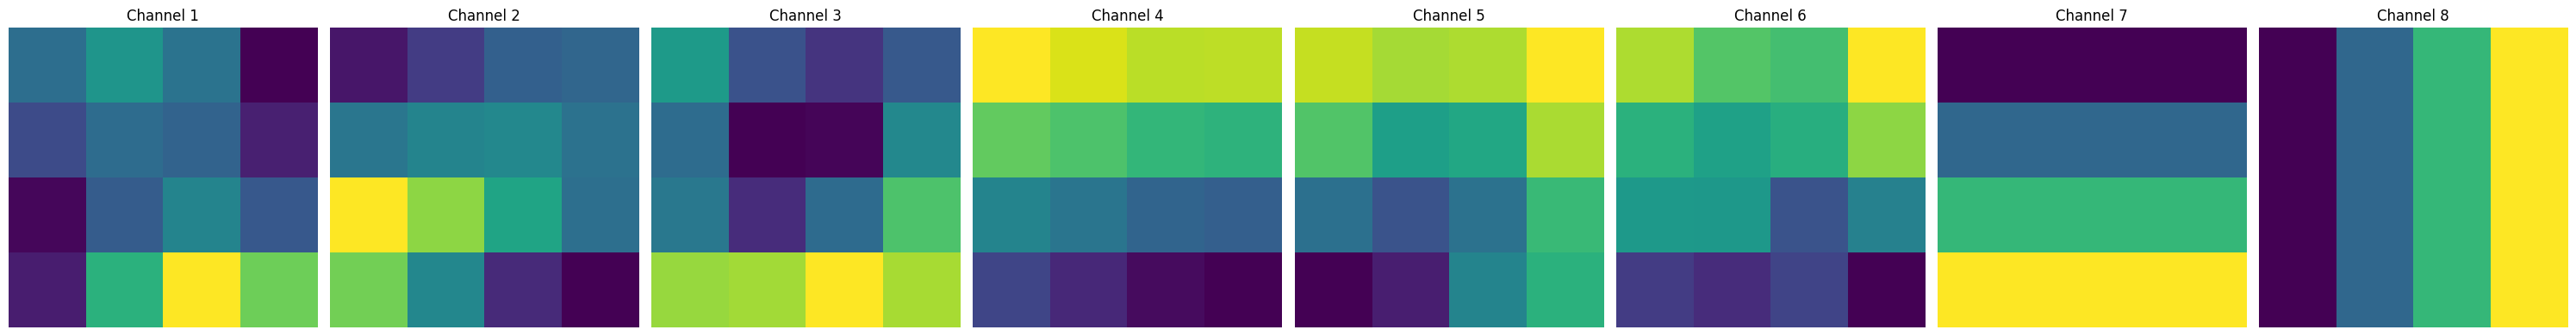

In [ ]:
transform = dataset.transform
dataset.transform = None 
img, label, info = dataset[num]
plt.figure(figsize=(30, 4))
for i in range(img.shape[0]):
    plt.subplot(1, img.shape[0], i + 1)
    plt.imshow(img[i], aspect='auto', cmap='viridis')
    plt.title(f'Channel {i+1}')
    plt.axis('off')
plt.axis('off')
plt.tight_layout()
plt.show()
dataset.transform = transform

### Training

#### Model and Optimizer Loading

In [51]:
# model = PixelWiseRegressor(dataset[0][0].shape[0], initial_conv_output=12)
# model = UNetRegression(in_channels=dataset[0][0].shape[0], out_channels=1, grid_size=6)
model = DA_CNN(in_channels=dataset[0][0].shape[0], out_channels=1, grid_size=12)
# model = SimplePixelRegressor(in_channels=dataset[0][0].shape[0], out_channels=1)
# model = UNetRegressionSE(in_channels=dataset[0][0].shape[0], out_channels=1, grid_size=6, base_filters=32, reduction=4)

In [52]:
def train_loop(model, train_dataloader, optimizer, loss_fn, device):
    size = len(train_dataloader)
    batch_size = train_dataloader.batch_size
    total_size = len(train_dataloader.dataset)
    model.train()
    total_loss = 0
    for batch, (images, labels, _) in enumerate(train_dataloader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        pred = model(images)
        loss = loss_fn(pred, labels.unsqueeze(1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        if batch % 50 == 0:
            loss, current = loss.item(), batch * batch_size + len(images)
            print(f"loss: {loss:>12f} [{current:>5d}/{total_size:>5d}]")
    total_loss /= size
    return total_loss

In [53]:
def val_loop(val_dataloader, model, loss_fn, device, scheduler):
    model.eval()
    num_batches = len(val_dataloader)
    val_loss = 0
    size = len(val_dataloader)
    with torch.no_grad():
        for image, label, _ in val_dataloader:
            image, label = image.to(device), label.to(device)
            pred = model(image)
            val_loss += loss_fn(pred, label.unsqueeze(1)).item()
    val_loss /= num_batches
    scheduler.step(val_loss)
    return val_loss

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

model = model.to(device)
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
# loss_fn = nn.L1Loss()
loss_fn = nn.MSELoss()

def initialize_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

model.apply(initialize_weights)

Using cuda device


DA_CNN(
  (convcam1): ConvReluBlock(
    (block): Sequential(
      (0): Conv2d(8, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (convcam2): ConvReluBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (cam): ChannelAttentionModule(
    (flatten): Flatten(start_dim=2, end_dim=-1)
    (softmax): Softmax(dim=2)
  )
  (convcam3): ConvReluBlock(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (convpam1): ConvReluBlock(
    (block): Sequential(
      (0): Conv2d(8, 64, kernel_size=(3, 3), stride=(1, 1), padding=(

#### No-Save Training Loop

In [27]:
for epoch in range(0, 5):
    print(f"Epoch {epoch+1}\n-------------------------------")
    train_loss = train_loop(model, train_loader, optimizer, loss_fn, device)
    print(f"Train loss: {train_loss:>8f}")
    val_loss = val_loop(val_loader, model, loss_fn, device, scheduler)
    print(f"Validation loss: {val_loss:>8f}\n")
    scheduler.step(train_loss)

Epoch 1
-------------------------------
loss:     2.276278 [   32/ 9338]
loss:     0.295133 [ 1632/ 9338]
loss:     0.277700 [ 3232/ 9338]
loss:     0.169082 [ 4832/ 9338]
loss:     0.308160 [ 6432/ 9338]
loss:     0.201049 [ 8032/ 9338]
Train loss: 0.358681
Validation loss: 0.292656

Epoch 2
-------------------------------
loss:     0.159296 [   32/ 9338]
loss:     0.201983 [ 1632/ 9338]
loss:     0.158872 [ 3232/ 9338]
loss:     0.247271 [ 4832/ 9338]
loss:     0.240887 [ 6432/ 9338]
loss:     0.190687 [ 8032/ 9338]
Train loss: 0.197235
Validation loss: 0.283191

Epoch 3
-------------------------------
loss:     0.287208 [   32/ 9338]
loss:     0.254814 [ 1632/ 9338]
loss:     0.134121 [ 3232/ 9338]
loss:     0.186987 [ 4832/ 9338]
loss:     0.159480 [ 6432/ 9338]
loss:     0.175545 [ 8032/ 9338]
Train loss: 0.182710
Validation loss: 0.264148

Epoch 4
-------------------------------
loss:     0.205498 [   32/ 9338]
loss:     0.198561 [ 1632/ 9338]
loss:     0.268681 [ 3232/ 9338]
los

#### Training Loop

In [55]:
from pathlib import Path
from utils.config import PROJECT_ROOT

save_path = Path(PROJECT_ROOT) / 'new_dataset_4' / f'{model.name()}+{dataset.season}+{dataset.coarsen}'
checkpoint_path = save_path / 'checkpoint.pt'
model_path = save_path / 'best_model.pt'


if not checkpoint_path.exists():
    save_path.mkdir(parents=True, exist_ok=True)
    best_val_loss = float('inf')
else:
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    scheduler.load_state_dict(checkpoint['scheduler_state'])
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    print(f"Loaded model with best validation loss: {best_val_loss:.6f}")

for epoch in range(0, 50):
    print(f"Epoch {epoch+1}\n-------------------------------")
    train_loss = train_loop(model, train_loader, optimizer, loss_fn, device)
    print(f"Train loss: {train_loss:>8f}")
    val_loss = val_loop(val_loader, model, loss_fn, device, scheduler)
    print(f"Validation loss: {val_loss:>8f}\n")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model, save_path / 'best_model.pt')
        print(f"New best model saved with validation loss: {val_loss:.6f}")
        checkpoint_dict = {
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'best_val_loss': best_val_loss
        }
        torch.save(checkpoint_dict, checkpoint_path)

Epoch 1
-------------------------------
loss:     1.166915 [   32/13804]
loss:     0.180460 [ 1632/13804]
loss:     0.059966 [ 3232/13804]
loss:     0.108669 [ 4832/13804]
loss:     0.114565 [ 6432/13804]
loss:     0.136431 [ 8032/13804]
loss:     0.180745 [ 9632/13804]
loss:     0.088976 [11232/13804]
loss:     0.093636 [12832/13804]
Train loss: 0.149064
Validation loss: 0.144238

New best model saved with validation loss: 0.144238
Epoch 2
-------------------------------
loss:     0.086192 [   32/13804]
loss:     0.207900 [ 1632/13804]
loss:     0.049012 [ 3232/13804]
loss:     0.100700 [ 4832/13804]
loss:     0.076128 [ 6432/13804]
loss:     0.121385 [ 8032/13804]
loss:     0.123780 [ 9632/13804]
loss:     0.146806 [11232/13804]
loss:     0.089315 [12832/13804]
Train loss: 0.098794
Validation loss: 0.057971

New best model saved with validation loss: 0.057971
Epoch 3
-------------------------------
loss:     0.087333 [   32/13804]
loss:     0.103998 [ 1632/13804]
loss:     0.096914 [

In [56]:
model = torch.load(model_path, weights_only=False)
model.eval()

DA_CNN(
  (convcam1): ConvReluBlock(
    (block): Sequential(
      (0): Conv2d(8, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (convcam2): ConvReluBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (cam): ChannelAttentionModule(
    (flatten): Flatten(start_dim=2, end_dim=-1)
    (softmax): Softmax(dim=2)
  )
  (convcam3): ConvReluBlock(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (convpam1): ConvReluBlock(
    (block): Sequential(
      (0): Conv2d(8, 64, kernel_size=(3, 3), stride=(1, 1), padding=(

### Inference

In [32]:
print("number of months for test set:", len(test_months))
print("number of points per month in test set:", len(test_indices) / len(test_months))
print("max and min latitude and longitude in test set:", dataset.max_lat, dataset.min_lat, dataset.max_long, dataset.min_long)

number of months for test set: 5
number of points per month in test set: 406.0
max and min latitude and longitude in test set: <xarray.DataArray 'latitude' ()> Size: 8B
array(61.) <xarray.DataArray 'latitude' ()> Size: 8B
array(40.5) <xarray.DataArray 'longitude' ()> Size: 8B
array(-127.) <xarray.DataArray 'longitude' ()> Size: 8B
array(-151.5)


#### Evaluation on Test Set

In [62]:
import scipy.ndimage as ndimage

mld_labels = np.zeros((len(test_months), len(dataset.argo_cut["latitude"]), len(dataset.argo_cut["longitude"])))
mld_preds = np.zeros((len(test_months), len(dataset.argo_cut["latitude"]), len(dataset.argo_cut["longitude"])))

print(mld_labels.shape, mld_preds.shape)
for X, y, extra_info in test_loader:
    X, y = X.to(device), y.to(device)
    preds = model(X)
    month_idx = int(extra_info[-1])
    month_pos = test_months.index(month_idx)
    lat = int((extra_info[0]).item() - dataset.argo_cut["latitude"].values.min())
    lon = int((extra_info[1]).item() - dataset.argo_cut["longitude"].values.min())
    time = extra_info[2]
    print(f"Processing month {month_idx}, lat {lat}, lon {lon}, time {time}")
    # mld_labels[month_pos, lat, lon] = y.item() * (dataset.maxs["mld"]- dataset.mins["mld"]) + dataset.mins["mld"]
    # mld_preds[month_pos, lat, lon] = preds.item() * (dataset.maxs["mld"]- dataset.mins["mld"]) + dataset.mins["mld"]
    mld_labels[month_pos, lat, lon] = y.item() * (dataset.stds["mld"]) + dataset.means["mld"]
    mld_preds[month_pos, lat, lon] = preds.item() * (dataset.stds["mld"]) + dataset.means["mld"]
mask = (mld_preds != 0).astype(float)  # shape (T, Y, X)

# 2) apply gaussian_filter to the masked data
masked_data = mld_preds * mask
smoothed_data = ndimage.gaussian_filter(masked_data,
                                        sigma=(0, 1, 1),
                                        order=0)

# 3) apply the same filter to the mask to get normalization weights
weights = ndimage.gaussian_filter(mask,
                                  sigma=(0, 1, 1),
                                  order=0)

# 4) avoid division by zero, then normalize
eps = 1e-8
normalized = np.zeros_like(mld_preds)
nonzero = mask.astype(bool)
normalized[nonzero] = smoothed_data[nonzero] / (weights[nonzero] + eps)

# anywhere the original was zero, keep it zero
mld_preds_smoothed = normalized

(5, 21, 25) (5, 21, 25)
Processing month 106, lat 0, lon 0, time ('2013-11-01T00:00:00.000000000',)
Processing month 106, lat 0, lon 1, time ('2013-11-01T00:00:00.000000000',)
Processing month 106, lat 0, lon 2, time ('2013-11-01T00:00:00.000000000',)
Processing month 106, lat 0, lon 3, time ('2013-11-01T00:00:00.000000000',)
Processing month 106, lat 0, lon 4, time ('2013-11-01T00:00:00.000000000',)
Processing month 106, lat 0, lon 5, time ('2013-11-01T00:00:00.000000000',)
Processing month 106, lat 0, lon 6, time ('2013-11-01T00:00:00.000000000',)
Processing month 106, lat 0, lon 7, time ('2013-11-01T00:00:00.000000000',)
Processing month 106, lat 0, lon 8, time ('2013-11-01T00:00:00.000000000',)
Processing month 106, lat 0, lon 9, time ('2013-11-01T00:00:00.000000000',)
Processing month 106, lat 0, lon 10, time ('2013-11-01T00:00:00.000000000',)
Processing month 106, lat 0, lon 11, time ('2013-11-01T00:00:00.000000000',)
Processing month 106, lat 0, lon 12, time ('2013-11-01T00:00:0

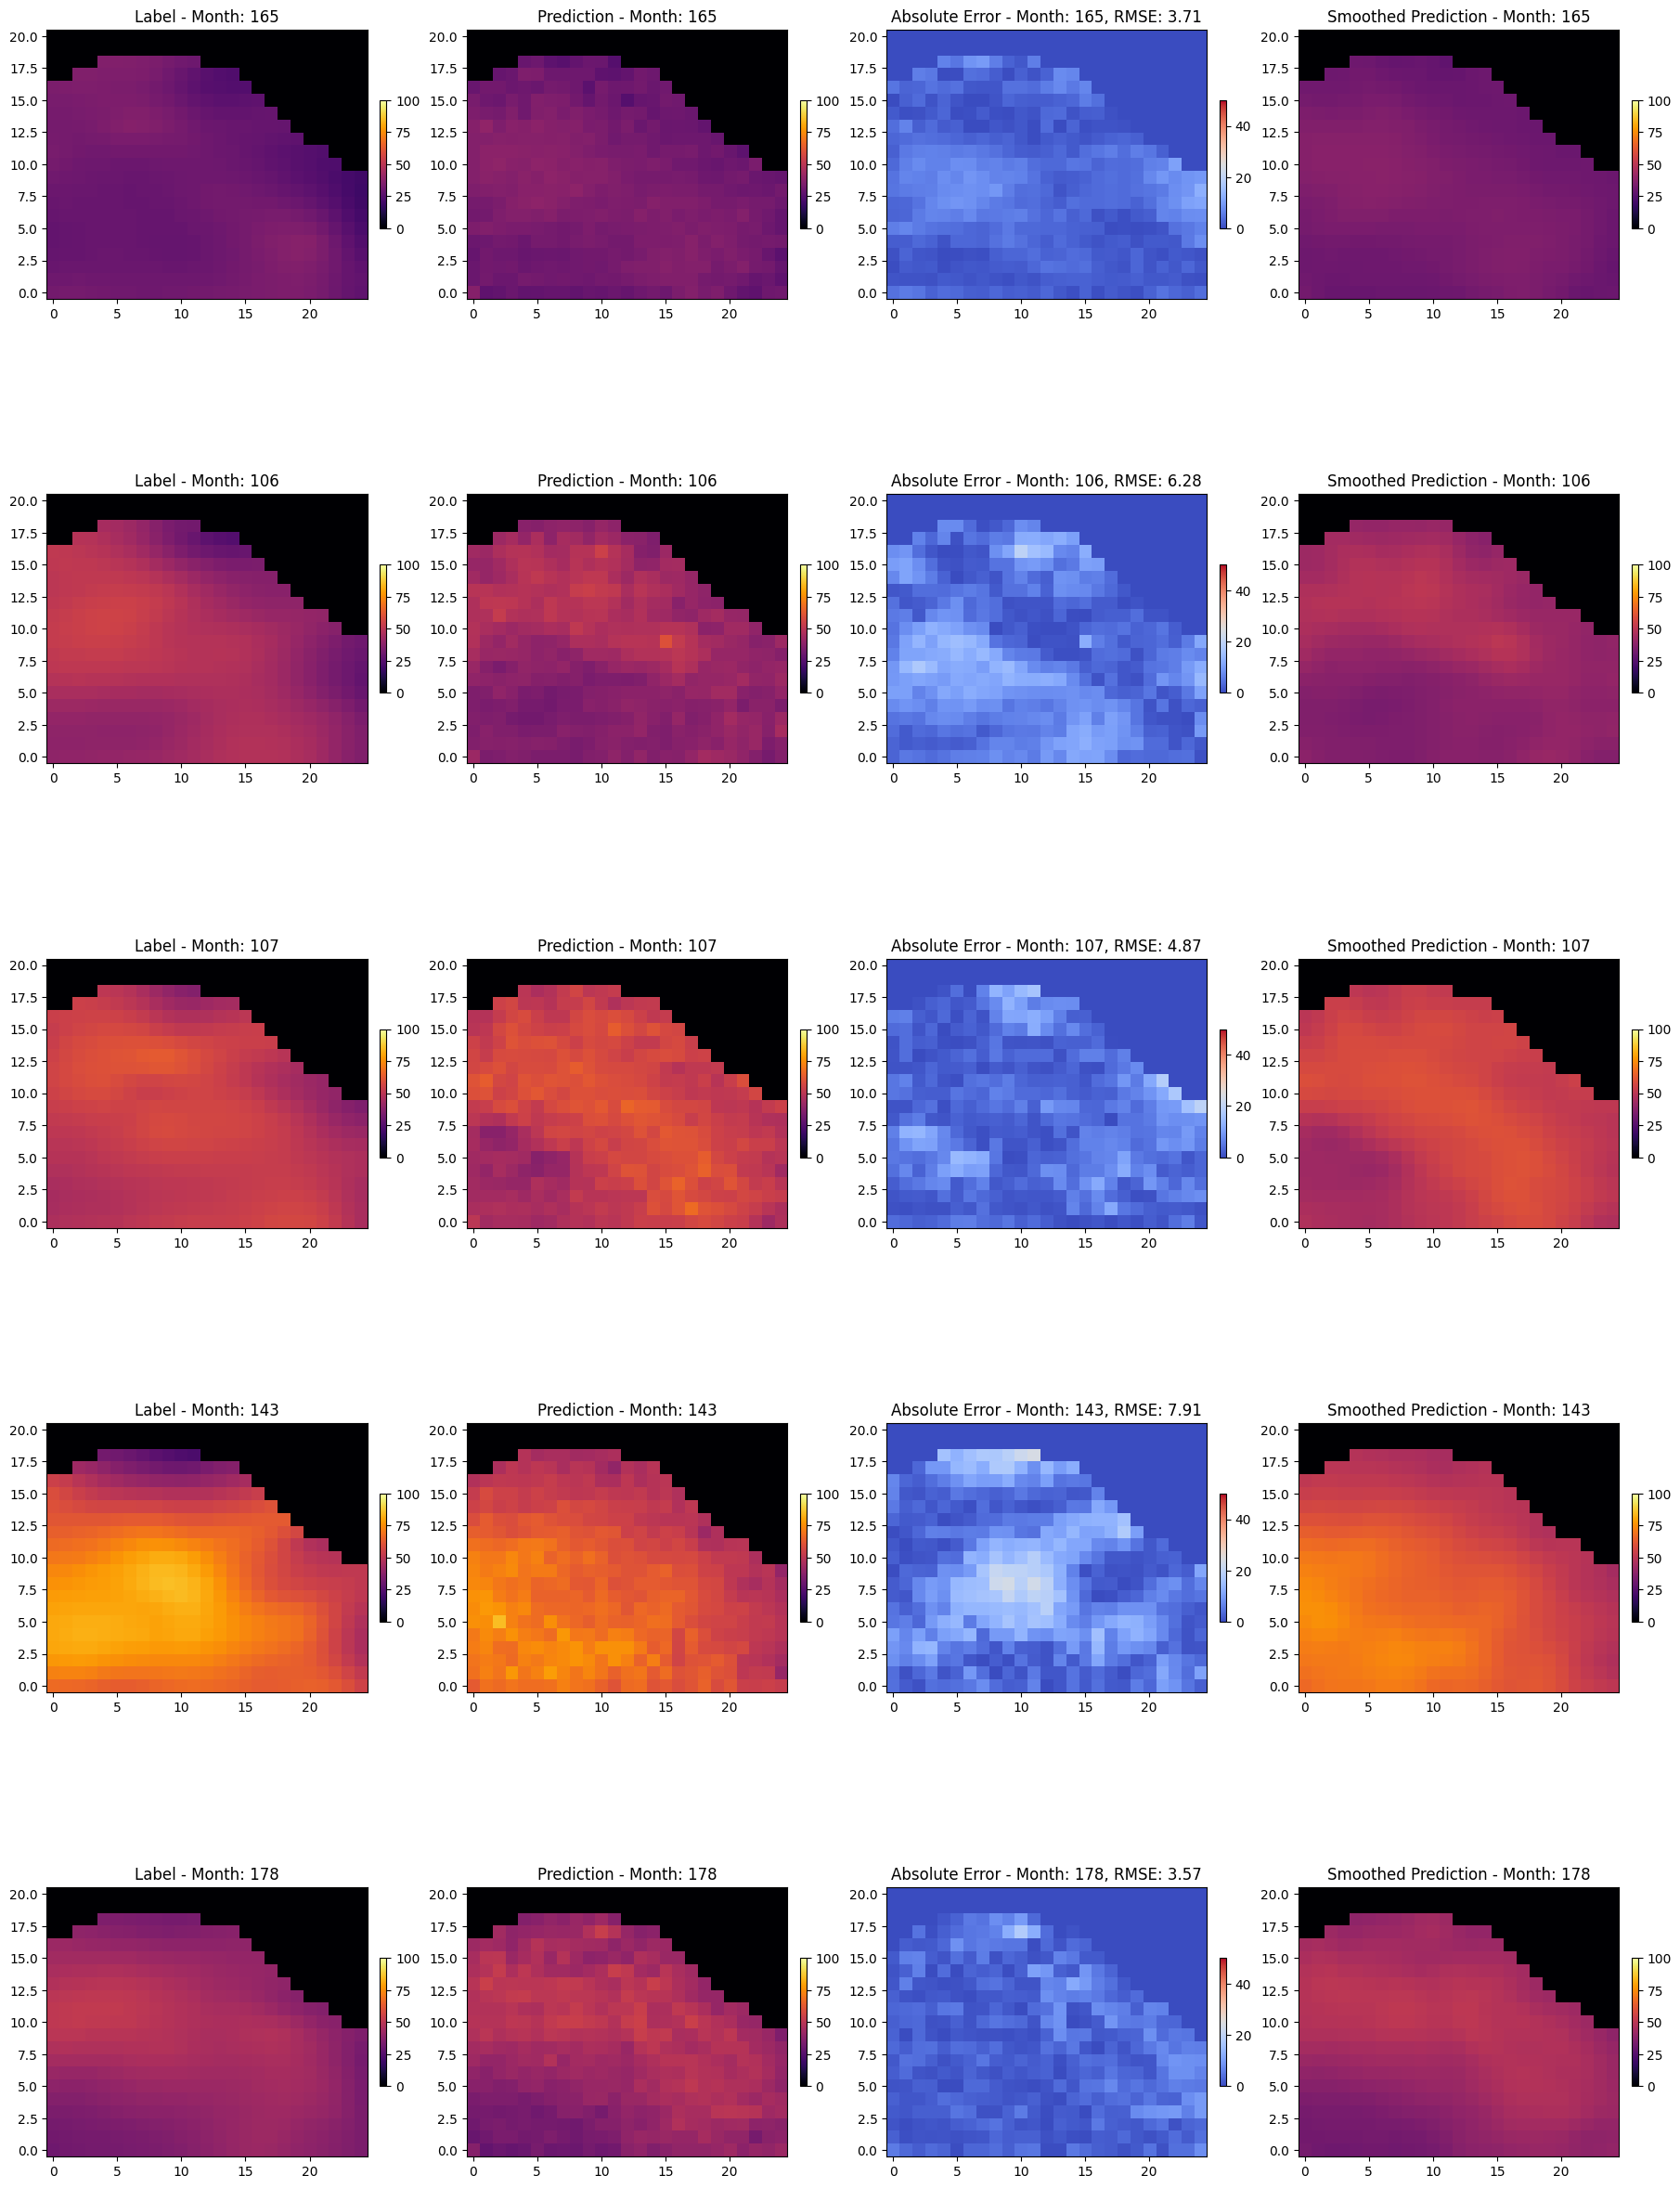

In [63]:
fig, axs = plt.subplots(len(test_months), 4, figsize=(18, 5 * len(test_months)), constrained_layout=True)
for i, month in enumerate(test_months):
    im_0 = axs[i, 0].imshow(mld_labels[i], cmap='inferno', vmin=0, vmax=100, origin='lower')
    fig.colorbar(im_0, ax=axs[i, 0], orientation='vertical', fraction=0.02, pad=0.04)
    axs[i, 0].set_title(f"Label - Month: {month}")
    im_1 = axs[i, 1].imshow(mld_preds[i], cmap='inferno', vmin=0, vmax=100, origin='lower')
    fig.colorbar(im_1, ax=axs[i, 1], orientation='vertical', fraction=0.02, pad=0.04)
    axs[i, 1].set_title(f"Prediction - Month: {month}")
    im_2 = axs[i, 2].imshow(abs(mld_labels[i] - mld_preds[i]), cmap='coolwarm', vmin=0, vmax=50, origin='lower')
    fig.colorbar(im_2, ax=axs[i, 2], orientation='vertical', fraction=0.02, pad=0.04)
    axs[i, 2].set_title(f"Absolute Error - Month: {month}, RMSE: {np.sqrt(np.mean((mld_labels[i] - mld_preds[i])**2)):.2f}")
    axs[i, 3].imshow(mld_preds_smoothed[i], cmap='inferno', vmin=0, vmax=100, origin='lower')
    fig.colorbar(axs[i, 3].imshow(mld_preds_smoothed[i], cmap='inferno', vmin=0, vmax=100, origin='lower'), ax=axs[i, 3], orientation='vertical', fraction=0.02, pad=0.04)
    axs[i, 3].set_title(f"Smoothed Prediction - Month: {month}")

#### Evaluation on Train Set

In [35]:
train_2_loader = DataLoader(train_subset, batch_size=1, shuffle=False)

mld_train_labels = np.zeros((len(train_months), len(dataset.argo_cut["latitude"]), len(dataset.argo_cut["longitude"])))
mld_train_preds = np.zeros((len(train_months), len(dataset.argo_cut["latitude"]), len(dataset.argo_cut["longitude"])))
print(mld_train_labels.shape, mld_train_preds.shape)
for X, y, extra_info in train_2_loader:
    X, y = X.to(device), y.to(device)
    preds = model(X)
    month_idx = int(extra_info[-1])
    month_pos = train_months.index(month_idx)
    lat = int((extra_info[0]).item() - dataset.argo_cut["latitude"].values.min())
    lon = int((extra_info[1]).item() - dataset.argo_cut["longitude"].values.min())
    time = extra_info[2]
    print(f"Processing month {month_idx}, lat {lat}, lon {lon}, time {time}")
    # mld_labels[month_pos, lat, lon] = y.item() * (dataset.maxs["mld"]- dataset.mins["mld"]) + dataset.mins["mld"]
    # mld_preds[month_pos, lat, lon] = preds.item() * (dataset.maxs["mld"]- dataset.mins["mld"]) + dataset.mins["mld"]
    mld_train_labels[month_pos, lat, lon] = y.item() * (dataset.stds["mld"]) + dataset.means["mld"]
    mld_train_preds[month_pos, lat, lon] = preds.item() * (dataset.stds["mld"]) + dataset.means["mld"]


(34, 21, 25) (34, 21, 25)
Processing month 9, lat 0, lon 0, time ('2005-10-01T00:00:00.000000000',)
Processing month 9, lat 0, lon 1, time ('2005-10-01T00:00:00.000000000',)
Processing month 9, lat 0, lon 2, time ('2005-10-01T00:00:00.000000000',)
Processing month 9, lat 0, lon 3, time ('2005-10-01T00:00:00.000000000',)
Processing month 9, lat 0, lon 4, time ('2005-10-01T00:00:00.000000000',)
Processing month 9, lat 0, lon 5, time ('2005-10-01T00:00:00.000000000',)
Processing month 9, lat 0, lon 6, time ('2005-10-01T00:00:00.000000000',)
Processing month 9, lat 0, lon 7, time ('2005-10-01T00:00:00.000000000',)
Processing month 9, lat 0, lon 8, time ('2005-10-01T00:00:00.000000000',)
Processing month 9, lat 0, lon 9, time ('2005-10-01T00:00:00.000000000',)
Processing month 9, lat 0, lon 10, time ('2005-10-01T00:00:00.000000000',)
Processing month 9, lat 0, lon 11, time ('2005-10-01T00:00:00.000000000',)
Processing month 9, lat 0, lon 12, time ('2005-10-01T00:00:00.000000000',)
Processin

KeyboardInterrupt: 

In [ ]:
fig, axs = plt.subplots(len(train_months), 3, figsize=(18, 6 * len(train_months)), constrained_layout=True)
for i, month in enumerate(train_months):
    im_0 = axs[i, 0].imshow(mld_train_labels[i], cmap='inferno', vmin=0, vmax=100, origin='lower')
    fig.colorbar(im_0, ax=axs[i, 0], orientation='vertical', fraction=0.02, pad=0.04)
    axs[i, 0].set_title(f"Label - Month: {month}")
    im_1 = axs[i, 1].imshow(mld_train_preds[i], cmap='inferno', vmin=0, vmax=100, origin='lower')
    fig.colorbar(im_1, ax=axs[i, 1], orientation='vertical', fraction=0.02, pad=0.04)
    axs[i, 1].set_title(f"Prediction - Month: {month}")
    im_2 = axs[i, 2].imshow(abs(mld_train_labels[i] - mld_train_preds[i]), cmap='coolwarm', vmin=0, vmax=50, origin='lower')
    fig.colorbar(im_2, ax=axs[i, 2], orientation='vertical', fraction=0.02, pad=0.04)
    axs[i, 2].set_title(f"Absolute Error - Month: {month}, MAE: {np.mean(abs(mld_train_labels[i] - mld_train_preds[i])):.2f}")

### Full Dataset

#### Loading

In [57]:
from utils.transforms import RescaledRotationTransform
transform = RescaledRotationTransform(scaling_interval=(1, 1.1))

In [134]:
import numpy as np
import torch

class FullDataset(myDataset):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.X, self.y = self.return_full_dataset()
        self.X = self.X.transpose(0, 3, 1, 2)
        self.X = np.nan_to_num(self.X)
        self.y = np.nan_to_num(self.y)
    def __len__(self):
        return len(self.full_indexes)
    def __getitem__(self, idx):
        img, label = self.X[idx], self.y[idx]
        label = np.expand_dims(label, 0)
        img = torch.tensor(img, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.float32)
        if self.transform:
            combined_transform = self.transform(torch.concatenate([img, label], dim=0))
            img = combined_transform[:img.shape[0]]
            label = combined_transform[img.shape[0]:]
        return img, label

dataset = FullDataset(transform=transform, season="autumn", coarsen=3)
dataset[0][0].shape, dataset[0][1].shape

(torch.Size([6, 82, 98]), torch.Size([1, 82, 98]))

In [148]:
class TestSubset(Subset):
    def __init__(self, dataset, indices):
        super().__init__(dataset, indices)
    def __getitem__(self, idx):
        original_idx = self.indices[idx]
        original_transform = self.dataset.transform
        self.dataset.transform = None  
        image, label = self.dataset[original_idx]
        self.dataset.transform = original_transform
        return image, label
    def __getitems__(self, indices: list[int]):
        if callable(getattr(self.dataset, "__getitems__", None)):
            return self.dataset.__getitems__([self.indices[idx] for idx in indices])  # type: ignore[attr-defined]
        else:
            return [self.__getitem__(idx) for idx in indices]

In [149]:
X, y = dataset[0]

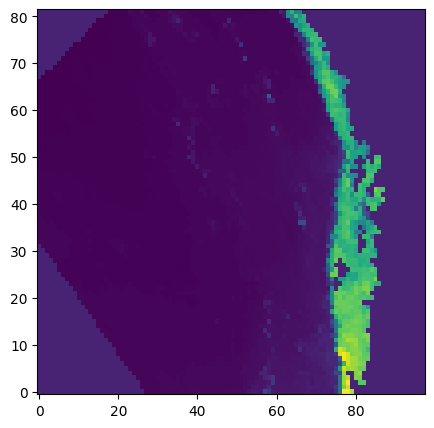

In [150]:
plt.figure(figsize=(5, 5))
plt.imshow(X[5], aspect='auto', cmap='viridis', origin='lower')

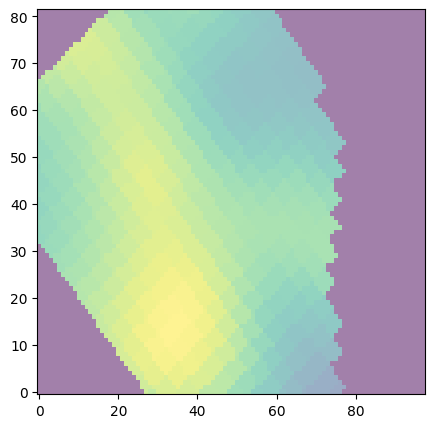

In [151]:
plt.figure(figsize=(5, 5))
plt.imshow(y[0], aspect='auto', cmap='viridis', origin='lower', alpha=0.5)

#### Data Preparation and Model Loading

In [152]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)

full_groups =  dataset.full_groups

train_val_indices, test_indices = next(gss.split(dataset.full_indexes, groups=full_groups))
print(len(train_val_indices), len(test_indices))

32 16


In [153]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_groups = [dataset.full_groups[i] for i in train_val_indices]
train_indices, val_indices = next(gss.split(train_val_indices, groups=train_val_groups))
print(len(train_indices), len(val_indices))
train_indices 

16 16


array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30])

In [154]:
train_months = list(set([train_val_groups[i] for i in train_indices]))

val_months = list(set([train_val_groups[i] for i in val_indices]))

test_months = list(set([dataset.groups[i] for i in test_indices]))

print(train_months)
print(val_months)
print(test_months)

intersection_months = list(set(train_months) & set(test_months))
print("Intersection of train and test months:", intersection_months)


[10]
[11]
[9]
Intersection of train and test months: []


In [155]:
train_indices = [train_val_indices[i] for i in train_indices]
val_indices = [train_val_indices[i] for i in val_indices]

In [156]:
train_subset = Subset(dataset, train_indices)
test_subset = TestSubset(dataset, test_indices)
val_subset = TestSubset(dataset, val_indices)

train_loader = DataLoader(train_subset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=1, shuffle=False)
val_loader = DataLoader(val_subset, batch_size=1, shuffle=True)

In [157]:
class BasicUNet(nn.Module):
    def __init__(self, in_channels, out_channels=1, grid_size=6, base_filters=64):
        """
        Basic UNet architecture for regression tasks.
        
        Args:
            in_channels: Number of input channels
            out_channels: Number of output channels (usually 1 for regression)
            grid_size: Size of the bottleneck feature map
            base_filters: Number of filters in the first layer, doubles at each level
        """
        super(BasicUNet, self).__init__()
        
        # Method to return model name
        self.name = lambda: "BasicUNet"
        
        # Feature sizes for each level
        self.features = [base_filters, base_filters*2, base_filters*4, base_filters*8]
        
        # Encoder
        self.encoder1 = self._double_conv(in_channels, self.features[0])
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder2 = self._double_conv(self.features[0], self.features[1])
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder3 = self._double_conv(self.features[1], self.features[2])
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Bottleneck
        self.bottleneck = self._double_conv(self.features[2], self.features[3])
        
        # Decoder
        self.upconv3 = nn.ConvTranspose2d(self.features[3], self.features[2], kernel_size=2, stride=2)
        self.decoder3 = self._double_conv(self.features[3], self.features[2])
        self.upconv2 = nn.ConvTranspose2d(self.features[2], self.features[1], kernel_size=2, stride=2)
        self.decoder2 = self._double_conv(self.features[2], self.features[1])
        self.upconv1 = nn.ConvTranspose2d(self.features[1], self.features[0], kernel_size=2, stride=2)
        self.decoder1 = self._double_conv(self.features[1], self.features[0])
        
        # Final output layer
        self.final = nn.Conv2d(self.features[0], out_channels, kernel_size=1)
    
    def _double_conv(self, in_channels, out_channels):
        """Helper method to create a double convolution block."""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        # Encoder path
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))
        enc3 = self.encoder3(self.pool2(enc2))
        
        # Bottleneck
        bottleneck = self.bottleneck(self.pool3(enc3))
        
        # Decoder path with skip connections
        dec3 = self.upconv3(bottleneck)
        if dec3.shape[2:] != enc3.shape[2:]:
            dec3 = nn.functional.interpolate(dec3, size=enc3.shape[2:], mode="bilinear", align_corners=True)
        dec3 = self.decoder3(torch.cat((enc3, dec3), dim=1))
        
        dec2 = self.upconv2(dec3)
        if dec2.shape[2:] != enc2.shape[2:]:
            dec2 = nn.functional.interpolate(dec2, size=enc2.shape[2:], mode="bilinear", align_corners=True)
        dec2 = self.decoder2(torch.cat((enc2, dec2), dim=1))
        
        dec1 = self.upconv1(dec2)
        if dec1.shape[2:] != enc1.shape[2:]:
            dec1 = nn.functional.interpolate(dec1, size=enc1.shape[2:], mode="bilinear", align_corners=True)
        dec1 = self.decoder1(torch.cat((enc1, dec1), dim=1))
        
        # Final convolution
        return self.final(dec1)

In [161]:
# model = PixelWiseRegressor(dataset[0][0].shape[0], initial_conv_output=12)
# model = UNetRegression(in_channels=dataset[0][0].shape[0], out_channels=1, grid_size=6)
model = BasicUNet(in_channels=dataset[0][0].shape[0], out_channels=1, grid_size=12)
# model = SimplePixelRegressor(in_channels=dataset[0][0].shape[0], out_channels=1)
# model = UNetRegressionSE(in_channels=dataset[0][0].shape[0], out_channels=1, grid_size=6, base_filters=32, reduction=4)
def train_loop(model, train_dataloader, optimizer, loss_fn, device):
    size = len(train_dataloader)
    batch_size = train_dataloader.batch_size
    total_size = len(train_dataloader.dataset)
    model.train()
    total_loss = 0
    for batch, (images, labels) in enumerate(train_dataloader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        pred = model(images)
        loss = loss_fn(pred, labels.unsqueeze(1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        if batch % 1 == 0:
            loss, current = loss.item(), batch * batch_size + len(images)
            print(f"loss: {loss:>12f} [{current:>5d}/{total_size:>5d}]")
    total_loss /= size
    return total_loss
def val_loop(val_dataloader, model, loss_fn, device, scheduler):
    model.eval()
    num_batches = len(val_dataloader)
    val_loss = 0
    size = len(val_dataloader)
    with torch.no_grad():
        for image, label in val_dataloader:
            image, label = image.to(device), label.to(device)
            pred = model(image)
            val_loss += loss_fn(pred, label.unsqueeze(1)).item()
    val_loss /= num_batches
    scheduler.step(val_loss)
    return val_loss

In [162]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

model = model.to(device)
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
# loss_fn = nn.L1Loss()
loss_fn = nn.MSELoss()

def initialize_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

model.apply(initialize_weights)

Using cuda device


BasicUNet(
  (encoder1): Sequential(
    (0): Conv2d(6, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(ke

#### Training

In [164]:
for epoch in range(0, 50):
    print(f"Epoch {epoch+1}\n-------------------------------")
    train_loss = train_loop(model, train_loader, optimizer, loss_fn, device)
    print(f"Train loss: {train_loss:>8f}")
    val_loss = val_loop(val_loader, model, loss_fn, device, scheduler)
    print(f"Validation loss: {val_loss:>8f}\n")
    scheduler.step(train_loss)

Epoch 1
-------------------------------
loss:     0.125376 [    1/   16]
loss:     1.095065 [    2/   16]
loss:     0.643606 [    3/   16]
loss:     0.167980 [    4/   16]
loss:     0.115539 [    5/   16]
loss:     1.104397 [    6/   16]
loss:     0.123289 [    7/   16]
loss:     0.847581 [    8/   16]
loss:     0.380015 [    9/   16]
loss:     0.904273 [   10/   16]
loss:     0.699437 [   11/   16]
loss:     0.520996 [   12/   16]
loss:     0.792346 [   13/   16]
loss:     1.561875 [   14/   16]
loss:     1.195501 [   15/   16]
loss:     0.419534 [   16/   16]
Train loss: 0.668551
Validation loss: 0.874144

Epoch 2
-------------------------------
loss:     0.766098 [    1/   16]
loss:     1.307015 [    2/   16]
loss:     0.801784 [    3/   16]
loss:     1.002825 [    4/   16]
loss:     0.783868 [    5/   16]
loss:     0.114116 [    6/   16]
loss:     0.106923 [    7/   16]
loss:     0.441987 [    8/   16]
loss:     0.143607 [    9/   16]
loss:     0.402240 [   10/   16]
loss:     0.82